# Training Models

# Linear Regression

### Normal Equation (Closed-form solution)

$$\hat{\boldsymbol{\theta}} = (\mathbf{X}^{\top} \mathbf{X})^{-1} \mathbf{X}^{\top} \mathbf{y}$$
θ : Model's parameter vector that minimizes the cost function

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [34]:
# Generating Linear looking data
np.random.seed(42)
X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + np.random.randn(100,1) # y = 3x + 4 (Actual Parameters) and some noise added

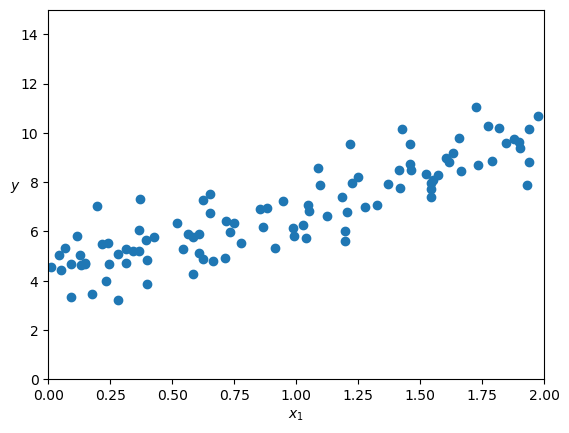

In [46]:
plt.scatter(X,y)
plt.axis([0,2,0,15])
plt.xlabel("$x_1$")
plt.ylabel("$y$",rotation=0)
plt.show()

In [35]:
# adding x0 = 1 to each instance to get the bias term
X_b = np.c_[np.ones((100,1)),X]
X_b[:5]

array([[1.        , 0.74908024],
       [1.        , 1.90142861],
       [1.        , 1.46398788],
       [1.        , 1.19731697],
       [1.        , 0.31203728]])

In [36]:
# Calculation Parameters using Normal Equation
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
theta_best # Close to 4x + 3

array([[4.21509616],
       [2.77011339]])

In [40]:
# Making Predictions using theta best
X_new = np.array([[0] , [2]])
X_new_b = np.c_[np.ones((2,1)),X_new]
X_new_b

array([[1., 0.],
       [1., 2.]])

In [41]:
y_predict = X_new_b.dot(theta_best)
y_predict

array([[4.21509616],
       [9.75532293]])

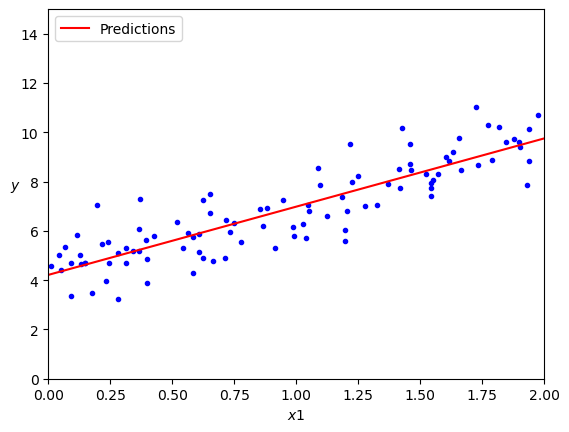

In [61]:
# Plotting
plt.plot(X,y,"b.")
plt.plot(X_new,y_predict,"r-",label="Predictions")
plt.axis([0,2,0,15])
plt.xlabel("$x1$")
plt.ylabel("$y$",rotation=0)
plt.legend(loc="upper left")
plt.show()

### Scikit-Learn Implementation

In [64]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()

In [66]:
lin_reg.fit(X,y)
lin_reg.intercept_ , lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [67]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

## Gradient Descent

$$\begin{array}{|l|c|c|c|}
\hline \textbf{Feature} & \textbf{Batch GD} & \textbf{Stochastic GD (SGD)} & \textbf{Mini-batch GD} \\
\hline \text{Data per step} & \text{Entire Dataset} & \text{1 Instance} & \text{Small Batch (e.g., 32)} \\
\hline \text{Speed} & \text{Slow} & \text{Fast} & \text{Moderate/Fast} \\
\hline \text{Path to Minimum} & \text{Smooth \& Direct} & \text{Erratic / Noisy} & \text{Slightly Noisy} \\
\hline \text{Hardware Usage} & \text{High Memory (RAM)} & \text{Low Memory} & \text{GPU Optimized} \\
\hline \text{Convergence} & \text{Stable} & \text{Never settles (jumps)} & \text{Stable with decay} \\
\hline
\end{array}$$

### Batch Gradient Descent

1) Partial derivatives of the cost function$$\frac{\partial}{\partial \theta_{j}} \operatorname{MSE}(\boldsymbol{\theta})=\frac{2}{m} \sum_{i=1}^{m}\left(\boldsymbol{\theta}^{\top} \mathbf{x}^{(i)}-y^{(i)}\right) x_{j}^{(i)}$$

2) Gradient vector of the cost function
$$\nabla_{\boldsymbol{\theta}} \text{MSE}(\boldsymbol{\theta}) = \begin{pmatrix} \frac{\partial}{\partial \theta_{0}} \text{MSE}(\boldsymbol{\theta}) \\ \frac{\partial}{\partial \theta_{1}} \text{MSE}(\boldsymbol{\theta}) \\ \vdots \\ \frac{\partial}{\partial \theta_{n}} \text{MSE}(\boldsymbol{\theta}) \end{pmatrix} = \frac{2}{m} \mathbf{X}^{\top} (\mathbf{X} \boldsymbol{\theta} - \mathbf{y})$$
$\nabla_{\boldsymbol{\theta}}$ (Nabla): This symbol represents the gradient (the vector of all partial derivatives).
$\mathbf{X}^{\top}$: The transpose of your feature matrix. This is what allows the math to "align" the errors with the correct features.
$(\mathbf{X} \boldsymbol{\theta} - \mathbf{y})$: This represents the prediction error. It's the difference between what the model guessed ($\mathbf{X} \boldsymbol{\theta}$) and the actual values ($\mathbf{y}$).

3) Gradient Descent step$$\boldsymbol{\theta}^{(\text {next step })}=\boldsymbol{\theta}-\eta \nabla_{\boldsymbol{\theta}} \operatorname{MSE}(\boldsymbol{\theta})$$
$\eta$ is the learning rate


In [68]:
eta = 0.1
n_iterations = 1000
m = 100
theta = np.random.randn(2,1) # random initialization of parameters

In [69]:
for iterations in range(n_iterations):
    gradients = 2/m*(X_b.T.dot(X_b.dot(theta)-y))
    theta = theta - eta*gradients

In [72]:
theta # got same optimal parameters

array([[4.21509616],
       [2.77011339]])

### Stochastic Gradient Descent

In [73]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=1000,tol=0.001,penalty=None,eta0=0.1)

In [78]:
sgd_reg.fit(X,y.ravel())

SGDRegressor(eta0=0.1, penalty=None)

In [79]:
sgd_reg.intercept_,sgd_reg.coef_

(array([4.28391129]), array([2.8926875]))

# Polynomial Regression

In [178]:
# Generating Non-Linear Data (Quadratic)
np.random.seed(42)
m = 100 # 100 training points
X = 6 * np.random.rand(m,1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m,1) # 0.5x^2 + x + 2 + noise

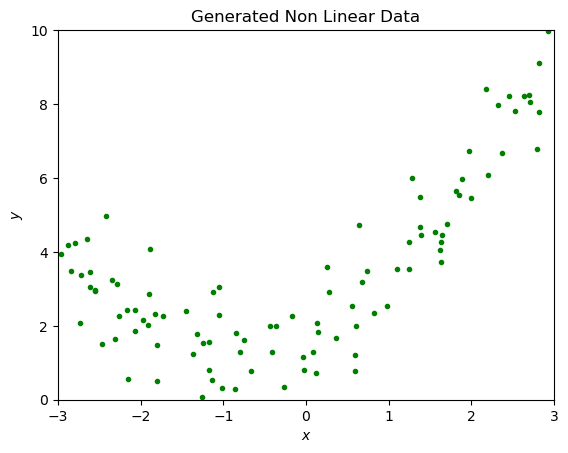

In [127]:
plt.title("Generated Non Linear Data")
plt.ylabel("$y$")
plt.xlabel("$x$")
plt.axis([-3,3,0,10])
plt.plot(X,y,"g.")
plt.show()

In [128]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2,include_bias=False)

In [129]:
X_poly = poly_features.fit_transform(X)

In [130]:
X[0] # only one feature

array([-0.75275929])

In [131]:
X_poly[0] # original feature along with another feature (X^2)

array([-0.75275929,  0.56664654])

In [133]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly,y)
lin_reg.intercept_,lin_reg.coef_ # Model's Estimation : y = 0.93x +  0.56x^2 + 1.78
                                 # Original:            y = 1.0x + 0.5x^2 + 2

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

In [139]:
y_predict = lin_reg.predict(X_poly)
y_predict[0]

array([1.39842532])

In [154]:
# SOrting Data in ascensing order for plotting
srt_idx = np.argsort(X.flatten())
X[srt_idx][:15],X[srt_idx][-15:]

(array([[-2.9668673 ],
        [-2.87649303],
        [-2.84748524],
        [-2.79366887],
        [-2.72863627],
        [-2.72129752],
        [-2.65149833],
        [-2.6186499 ],
        [-2.60969044],
        [-2.55573209],
        [-2.55269614],
        [-2.46904499],
        [-2.41396732],
        [-2.35265144],
        [-2.30478564]]),
 array([[1.97242505],
        [1.99465584],
        [2.17862056],
        [2.19705687],
        [2.32327646],
        [2.3689641 ],
        [2.45592241],
        [2.53124541],
        [2.63699365],
        [2.69331322],
        [2.70428584],
        [2.7937922 ],
        [2.81750777],
        [2.81945911],
        [2.92132162]]))

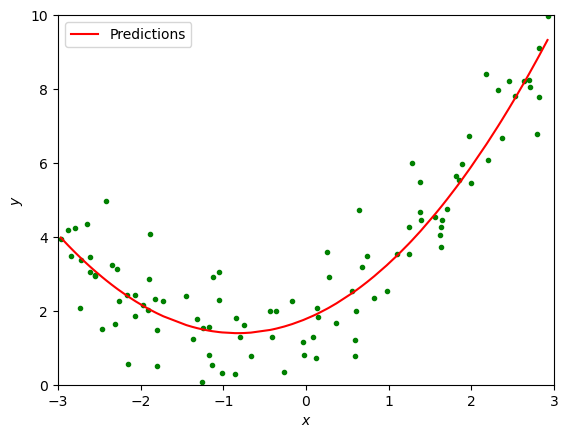

In [141]:
plt.ylabel("$y$")
plt.xlabel("$x$")
plt.axis([-3,3,0,10])
plt.plot(X,y,"g.")
plt.plot(X[srt_idx],y_predict[srt_idx],"r-",label="Predictions")
plt.legend(loc="upper left")
plt.show()

In [160]:
# Method-2 (# Create 100 points in order from -3 to 3) --> will get predictions for new unknown values also
X_new = np.linspace(-3,3,100).reshape(-1,1)
X_new[:15],X_new[-15:]

(array([[-3.        ],
        [-2.93939394],
        [-2.87878788],
        [-2.81818182],
        [-2.75757576],
        [-2.6969697 ],
        [-2.63636364],
        [-2.57575758],
        [-2.51515152],
        [-2.45454545],
        [-2.39393939],
        [-2.33333333],
        [-2.27272727],
        [-2.21212121],
        [-2.15151515]]),
 array([[2.15151515],
        [2.21212121],
        [2.27272727],
        [2.33333333],
        [2.39393939],
        [2.45454545],
        [2.51515152],
        [2.57575758],
        [2.63636364],
        [2.6969697 ],
        [2.75757576],
        [2.81818182],
        [2.87878788],
        [2.93939394],
        [3.        ]]))

In [161]:
X_new_poly = poly_features.transform(X_new)
X_new_poly[0]

array([-3.,  9.])

In [162]:
y_predict_new =  lin_reg.predict(X_new_poly)
y_predict_new[0]

array([4.06140272])

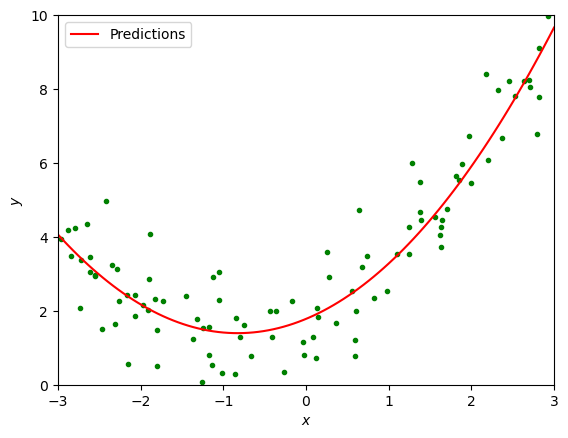

In [163]:
plt.ylabel("$y$")
plt.xlabel("$x$")
plt.axis([-3,3,0,10])
plt.plot(X,y,"g.")
plt.plot(X_new,y_predict_new,"r-",label="Predictions")
plt.legend(loc="upper left")
plt.show()

## Learning Curves

In [166]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [211]:
def plot_learning_curves(model,X,y):
    X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.2,random_state=42)
    train_errors,val_errors = [],[]

    for m in range(1,len(X_train)):
        model.fit(X_train[:m],y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m],y_train_predict))
        val_errors.append(mean_squared_error(y_val,y_val_predict))
        
    plt.plot(np.sqrt(train_errors),"r-",label="train")
    plt.plot(np.sqrt(val_errors),"b-",label="val")
    plt.xlabel("Training set Size")
    plt.ylabel("RMSE")
    plt.title("Learning Curves")
    plt.axis([0,80,0,3])
    plt.legend()
    plt.show()

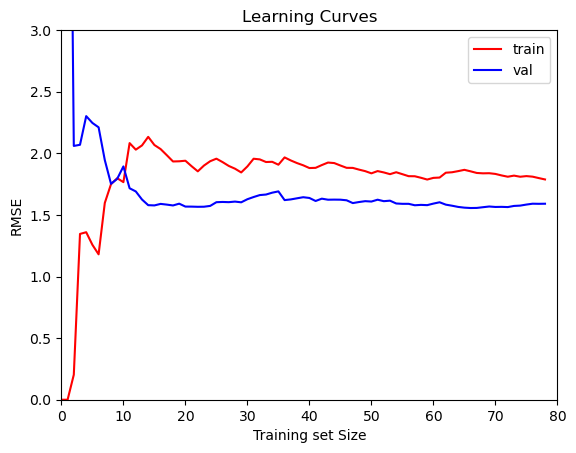

In [216]:
lin_reg = LinearRegression() # Underfitted Model
plot_learning_curves(lin_reg,X,y)

In [219]:
# Trying a very complex model (degree=10) that will cause the model to overfit
from sklearn.pipeline import Pipeline
polynomial_regression = Pipeline([
    ("poly_features",PolynomialFeatures(degree=10,include_bias=False)),
    ("lin_reg",LinearRegression())
])

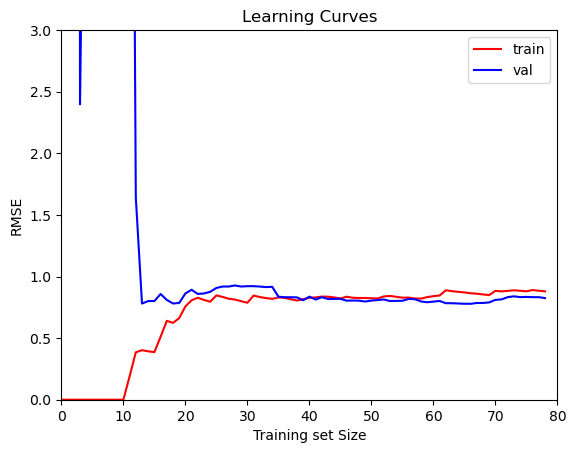

In [220]:
plot_learning_curves(polynomial_regression,X,y) # Overfitted Model

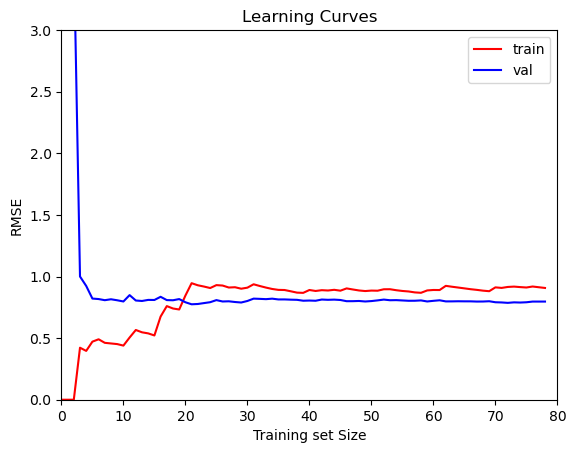

In [225]:
# Good Model --> Degree = 2
polynomial_regression_quad = Pipeline([
    ("poly_features",PolynomialFeatures(degree=2,include_bias=False)),
    ("lin_reg",LinearRegression())
])
plot_learning_curves(polynomial_regression_quad,X,y)

 # Regularized Linear Regression

## Ridge Regression

$$J(\boldsymbol{\theta}) = \text{MSE}(\boldsymbol{\theta}) + \alpha \frac{1}{2} \sum_{i=1}^{n} \theta_{i}^{2}$$

$J(\boldsymbol{\theta})$: This is the new cost function that the model tries to minimize.

$\text{MSE}(\boldsymbol{\theta})$: The standard Mean Squared Error (how far off the predictions are).

$\alpha \frac{1}{2} \sum_{i=1}^{n} \theta_{i}^{2}$: This is the Regularization term (L2 penalty).It forces the learning algorithm to not only fit the data but also keep the model weights ($\theta$) as small as possible.

$\alpha$ (Alpha): Controls how much you want to regularize the model. If $\alpha = 0$, you just have standard Linear Regression. If $\alpha$ is very large, all weights end up very close to zero, resulting in a flat line.

### Ridge Regression closed-form solution

$$\hat{\boldsymbol{\theta}} = \left( \mathbf{X}^{\top} \mathbf{X} + \alpha \mathbf{A} \right)^{-1} \mathbf{X}^{\top} \mathbf{y}$$

In Standard Normal Equation ($\hat{\boldsymbol{\theta}} = (\mathbf{X}^{\top} \mathbf{X})^{-1} \mathbf{X}^{\top} \mathbf{y}$), the only change is the addition of $+\alpha \mathbf{A}$ inside the inverse.

$\alpha$ (Alpha): The regularization hyperparameter.

$\mathbf{A}$:$(n+1) \times (n+1)$ identity matrix, but with a 0 in the top-left cell, because in Ridge Regression, we do not want to penalize the bias term ($\theta_0$). By putting a 0 there, the bias remains unconstrained while all other weights are pushed toward zero.

In [281]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1,solver="cholesky")
ridge_reg.fit(X_poly,y)
ridge_reg.coef_,ridge_reg.intercept_ # Model's Estimation : y = 0.93x +  0.56x^2 + 1.78
                                     # Original:            y = 1.0x + 0.5x^2 + 2

(array([0.9305576 , 0.56355288]), array([1.78400638]))

In [282]:
from sklearn.preprocessing import StandardScaler
ridge_poly_reg = Pipeline([
    ("poly_features",PolynomialFeatures(degree=2,include_bias=False)),
    #("std_scaler",StandardScaler()),
    ("ridge_reg",Ridge(alpha=1,solver="cholesky"))
])

In [283]:
ridge_poly_reg.fit(X,y)
coeffs = ridge_poly_reg.named_steps["ridge_reg"].coef_
intercept = ridge_poly_reg.named_steps["ridge_reg"].intercept_

In [284]:
coeffs,intercept

(array([0.9305576 , 0.56355288]), array([1.78400638]))

### Ridge Regression using Gradient Descent

In [285]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=1000,tol=0.001,penalty="l2",eta0=0.1)

In [286]:
sgd_reg.fit(X_poly,y.ravel())
sgd_reg.coef_,sgd_reg.intercept_

(array([0.98317781, 0.56298317]), array([1.77711845]))

## Laso Regression

$$J(\boldsymbol{\theta}) = \text{MSE}(\boldsymbol{\theta}) + \alpha \sum_{i=1}^{n} |\theta_{i}|$$

Ridge (L2 Norm): Uses the square of the weights ($\theta_i^2$). This tends to make weights small but rarely zero.

Lasso (L1 Norm): Uses the absolute value of the weights ($|\theta_i|$).

In [288]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)

In [291]:
lasso_reg.fit(X_poly,y)
lasso_reg.coef_,lasso_reg.intercept_

(array([0.89934151, 0.54811812]), array([1.82759877]))

In [293]:
sgd_reg = SGDRegressor(max_iter=1000,tol=0.001,penalty="l1",eta0=0.1)
sgd_reg.fit(X_poly,y.ravel())
sgd_reg.coef_,sgd_reg.intercept_

(array([1.0368041 , 0.55041891]), array([1.81616639]))

## Elastic Net

$$J(\boldsymbol{\theta}) = \text{MSE}(\boldsymbol{\theta}) + r \alpha \sum_{i=1}^{n} |\theta_{i}| + \frac{1 - r}{2} \alpha \sum_{i=1}^{n} \theta_{i}^{2}$$

Elastic Net is the ultimate "middle ground." It is a weighted combination of both Lasso Regression and Ridge Regression.

The L1 Term ($r \alpha \sum |\theta_i|$): This is the Lasso part.

The L2 Term ($\frac{1-r}{2} \alpha \sum \theta_i^2$): This is the Ridge part.

The Mix Ratio ($r$)The parameter $r$ is the mix ratio:When $r = 1$, Elastic Net is equivalent to Lasso.When $r = 0$, Elastic Net is equivalent to Ridge.Anywhere in between, you get a model that can perform feature selection (like Lasso) while still being stable when features are highly correlated (like Ridge).

In [294]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1,l1_ratio=0.5) # l1 ratio is the mis ratio(r)

In [296]:
elastic_net.fit(X_poly,y)
elastic_net.coef_,elastic_net.intercept_

(array([0.90142924, 0.55141065]), array([1.81748182]))

# Logistic Regression

 Logistic Regression cost function (log loss)$$J(\boldsymbol{\theta}) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log \left( \hat{p}^{(i)} \right) + \left( 1 - y^{(i)} \right) \log \left( 1 - \hat{p}^{(i)} \right) \right]$$

 Logistic cost function partial derivatives$$\frac{\partial}{\partial \theta_{j}} J(\boldsymbol{\theta}) = \frac{1}{m} \sum_{i=1}^{m} \left( \sigma \left( \boldsymbol{\theta}^{\top} \mathbf{x}^{(i)} \right) - y^{(i)} \right) x_{j}^{(i)}$$

$\hat{p}^{(i)}$: The predicted probability that the $i^{th}$ instance belongs to the positive class (computed as $\sigma(\boldsymbol{\theta}^T \mathbf{x}^{(i)})$).

$\sigma$: The Sigmoid function (Logistic function), defined as $\sigma(t) = \frac{1}{1 + \exp(-t)}$.

In [297]:
from sklearn import datasets

In [298]:
iris = datasets.load_iris()

In [326]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

### Binary classifier to detect the Iris virginica type based only on the petal width feature

In [309]:
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [313]:
X = iris["data"][:,3:] # petal width
X[:10]

array([[0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.4],
       [0.3],
       [0.2],
       [0.2],
       [0.1]])

In [319]:
y = (iris["target"] == 2).astype(np.int_) # Targets (Yes/No)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [320]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()

In [322]:
log_reg.fit(X,y)
log_reg.coef_,log_reg.intercept_

(array([[4.33251974]]), array([-7.19342106]))

In [323]:
y_predict = log_reg.predict(X)
y_predict

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [331]:
y_prob = log_reg.predict_proba(X) 
y_prob # [No,yes] probabilities

array([[0.99821565, 0.00178435],
       [0.99821565, 0.00178435],
       [0.99821565, 0.00178435],
       [0.99821565, 0.00178435],
       [0.99821565, 0.00178435],
       [0.9957662 , 0.0042338 ],
       [0.99725073, 0.00274927],
       [0.99821565, 0.00178435],
       [0.99821565, 0.00178435],
       [0.99884231, 0.00115769],
       [0.99821565, 0.00178435],
       [0.99821565, 0.00178435],
       [0.99884231, 0.00115769],
       [0.99884231, 0.00115769],
       [0.99821565, 0.00178435],
       [0.9957662 , 0.0042338 ],
       [0.9957662 , 0.0042338 ],
       [0.99725073, 0.00274927],
       [0.99725073, 0.00274927],
       [0.99725073, 0.00274927],
       [0.99821565, 0.00178435],
       [0.9957662 , 0.0042338 ],
       [0.99821565, 0.00178435],
       [0.99348532, 0.00651468],
       [0.99821565, 0.00178435],
       [0.99821565, 0.00178435],
       [0.9957662 , 0.0042338 ],
       [0.99821565, 0.00178435],
       [0.99821565, 0.00178435],
       [0.99821565, 0.00178435],
       [0.

In [332]:
# Taking 100 samples with petal width between 0-3 cm
X_new = np.linspace(0,3,1000).reshape(-1,1)
y_proba = log_reg.predict_proba(X_new)

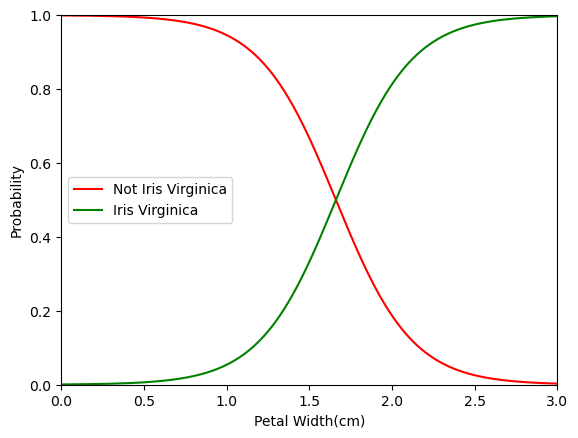

In [334]:
plt.plot(X_new,y_proba[:,0],"r-",label="Not Iris Virginica")
plt.plot(X_new,y_proba[:,1],"g-",label="Iris Virginica")
plt.axis([0,3,0,1])
plt.xlabel("Petal Width(cm)")
plt.ylabel("Probability")
plt.legend(loc="center left")
plt.show()

In [336]:
# Decision Boudary around 1.6cm
log_reg.predict([[1.5],[1.7]]) # 1.5cm and 1.7 cm will give 0 and 1 respectively

array([0, 1])

### Binary Classifier to detect the Iris virginica type based on the petal lenght and petal width feature

In [339]:
X = iris["data"][:,2:]
X # [Petal Length,Petal Width]

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.7, 0.4],
       [1.4, 0.3],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.5, 0.1],
       [1.5, 0.2],
       [1.6, 0.2],
       [1.4, 0.1],
       [1.1, 0.1],
       [1.2, 0.2],
       [1.5, 0.4],
       [1.3, 0.4],
       [1.4, 0.3],
       [1.7, 0.3],
       [1.5, 0.3],
       [1.7, 0.2],
       [1.5, 0.4],
       [1. , 0.2],
       [1.7, 0.5],
       [1.9, 0.2],
       [1.6, 0.2],
       [1.6, 0.4],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.6, 0.2],
       [1.6, 0.2],
       [1.5, 0.4],
       [1.5, 0.1],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.2, 0.2],
       [1.3, 0.2],
       [1.4, 0.1],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.3, 0.3],
       [1.3, 0.3],
       [1.3, 0.2],
       [1.6, 0.6],
       [1.9, 0.4],
       [1.4, 0.3],
       [1.6, 0.2],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [4.7, 1.4],
       [4.5, 1.5],
       [4.9,

In [341]:
y = (iris["target"]==2).astype(np.int_)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [343]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()

In [346]:
log_reg.fit(X,y)
log_reg.coef_,log_reg.intercept_ # w1x1 + w2x2 + b

(array([[2.77983942, 2.38388751]]), array([-17.55616979]))

In [349]:
w1,w2,b = log_reg.coef_[0,0],log_reg.coef_[0,1],log_reg.intercept_[0]
w1,w2,b

(np.float64(2.7798394168829343),
 np.float64(2.383887514587646),
 np.float64(-17.556169786543396))

In [352]:
y_predict = log_reg.predict(X)
y_predict

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Plotting Decision Boundary
$$w_1x_1 + w_2x_2 + b = 0$$
$$x_2 = -\left(\frac{w_1}{w_2}\right)x_1 - \frac{b}{w_2}$$
Slope ($m$): $-\frac{w_1}{w_2}$

Intercept ($c$): $-\frac{b}{w_2}$

x1: Petal Lenght

x2: Petal Width

In [387]:
x1 = np.linspace(X[:,0].min(),X[:,0].max(),1000).reshape(-1,1)
x2 = -(w1/w2)*x1 - (b/w2)

array([[ 6.19841762e+00],
       [ 6.19153077e+00],
       [ 6.18464392e+00],
       [ 6.17775708e+00],
       [ 6.17087023e+00],
       [ 6.16398338e+00],
       [ 6.15709653e+00],
       [ 6.15020968e+00],
       [ 6.14332284e+00],
       [ 6.13643599e+00],
       [ 6.12954914e+00],
       [ 6.12266229e+00],
       [ 6.11577545e+00],
       [ 6.10888860e+00],
       [ 6.10200175e+00],
       [ 6.09511490e+00],
       [ 6.08822806e+00],
       [ 6.08134121e+00],
       [ 6.07445436e+00],
       [ 6.06756751e+00],
       [ 6.06068067e+00],
       [ 6.05379382e+00],
       [ 6.04690697e+00],
       [ 6.04002012e+00],
       [ 6.03313328e+00],
       [ 6.02624643e+00],
       [ 6.01935958e+00],
       [ 6.01247273e+00],
       [ 6.00558588e+00],
       [ 5.99869904e+00],
       [ 5.99181219e+00],
       [ 5.98492534e+00],
       [ 5.97803849e+00],
       [ 5.97115165e+00],
       [ 5.96426480e+00],
       [ 5.95737795e+00],
       [ 5.95049110e+00],
       [ 5.94360426e+00],
       [ 5.9

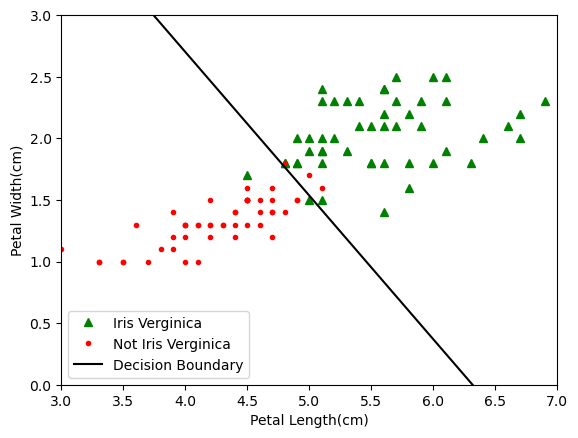

In [389]:
# Separating the data for plotting
verginica = (y==1)
not_verginica = (y==0)

plt.plot(X[verginica,0],X[verginica,1],"g^",label="Iris Verginica")
plt.plot(X[not_verginica,0],X[not_verginica,1],"r.",label="Not Iris Verginica")

plt.plot(x1,x2,"black",label="Decision Boundary")
plt.xlabel("Petal Length(cm)")
plt.axis([3,7,0,3])
plt.ylabel("Petal Width(cm)")
plt.legend(loc="best")
plt.show()

# Softmax / Multinomial Logistic Regression

1. Softmax score for class $k$$$s_{k}(\mathbf{x}) = \mathbf{x}^{\top} \boldsymbol{\theta}^{(k)}$$

$s_{k}(\mathbf{x})$: The score (logit) for class $k$.

$\mathbf{x}$: The feature vector of the instance.

$\boldsymbol{\theta}^{(k)}$: The parameter vector specific to class $k$. Every class has its own set of weights.

2. Softmax function$$\hat{p}_{k} = \sigma(\mathbf{s}(\mathbf{x}))_{k} = \frac{\exp \left(s_{k}(\mathbf{x})\right)}{\sum_{j=1}^{K} \exp \left(s_{j}(\mathbf{x})\right)}$$

$\hat{p}_{k}$: The predicted probability that the instance belongs to class $k$

3. Cross entropy cost function$$J(\boldsymbol{\Theta}) = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_{k}^{(i)} \log \left(\hat{p}_{k}^{(i)}\right)$$

$y_{k}^{(i)}$: The target probability (1 if the $i^{th}$ instance belongs to class $k$, and 0 otherwise).

### Predicting Multiple Classes

In [391]:
from sklearn.linear_model import LogisticRegression
softmax_reg = LogisticRegression(multi_class="multinomial",solver="lbfgs",C=10)

In [395]:
X = iris["data"][:,(2,3)] # [Petal lenght, Petal Width]
y = iris["target"] 
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [399]:
iris["target_names"] # 0,1,2 respectively

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [401]:
softmax_reg.fit(X,y)
softmax_reg.coef_,softmax_reg.intercept_

C:\Users\bhatm\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


(array([[-4.60034278, -2.23391332],
        [ 0.16193991, -2.16378762],
        [ 4.43840287,  4.39770094]]),
 array([ 18.91470032,   6.39571053, -25.31041085]))

In [405]:
y_predict = softmax_reg.predict(X)
y_predict

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [404]:
y_predict == y

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True, False,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,